# 02 - Mentions over time (per ticker)

**What this does:** reads the cleaned posts, finds the stock tickers in each
post, and counts mentions per day. It makes **two graphs**:

1. **Raw mentions** - every post counts as 1.
2. **Upvote-weighted mentions** - each mention is weighted by the post's upvotes
   (score). This leans on what the crowd actually pushed up, so a few high-upvote
   posts matter more than lots of ignored ones.

It saves `data/processed/daily_ticker_counts.parquet` (with both columns), which
notebook 03 uses.

_Note:_ the first run downloads the official Nasdaq ticker list (needs internet)
and caches it under `data/reference/`.

In [49]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [50]:
# ============ TIME WINDOW - edit freely ============
# Keep this narrow to keep runs fast. Rough guide with ALL 15 subreddits:
#   1 year  ~ 700k posts  -> notebook 02 scan: a few minutes
#   all dates = 7.9M posts -> 02: ~30-60 min, 04 (themes): many HOURS
# Set both to None for the full 2008-2025 history.
START_DATE = '2021-01-01'   # inclusive,  'YYYY-MM-DD' or None
END_DATE   = '2022-01-01'   # EXCLUSIVE,  'YYYY-MM-DD' or None
# ====================================================

In [51]:
# ============ PARAMETERS - edit these ============
POSTS_PATH        = os.path.join(ROOT, 'data', 'processed', 'posts.parquet')
SUBREDDITS        = []      # ALL 15 subreddits (7.9M posts - the scan takes a while!)
CASHTAGS_ONLY     = False   # True = only count $TICKER (cleaner, fewer false hits)
TICKERS_TO_PLOT   = []      # e.g. ['GME', 'AMC']; [] = use the TOP_N most mentioned
TOP_N             = 6
DAILY_COUNTS_OUT  = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts.parquet')
# ==================================================

In [52]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from src.ticker_universe import load_us_ticker_universe
from src.build_mentions import build_daily_counts

# Read ONLY the columns and subreddits we need, straight from the parquet.
# The reader skips row groups that can't match, so this stays fast.
filters = []
if SUBREDDITS:
    filters.append(('subreddit', 'in', [s.lower() for s in SUBREDDITS]))
if START_DATE:
    filters.append(('date', '>=', START_DATE))
if END_DATE:
    filters.append(('date', '<', END_DATE))

posts = pq.read_table(
    POSTS_PATH,
    columns=['date', 'title', 'selftext', 'score'],
    filters=filters if filters else None,
).to_pandas()
print('posts:', f'{len(posts):,}')

# Valid US tickers (cached after first download).
universe = load_us_ticker_universe(Path(ROOT) / 'data' / 'reference', max_cache_age_days=7)
print('ticker universe size:', len(universe))

# daily now has BOTH: mention_count (raw) and weighted_count (by upvotes).
daily = build_daily_counts(posts, universe, cashtags_only=CASHTAGS_ONLY)
daily.to_parquet(DAILY_COUNTS_OUT, index=False)
print('daily count rows:', len(daily), '-> saved', DAILY_COUNTS_OUT)
daily.head()

posts: 2,832,937
ticker universe size: 12314
daily count rows: 169883 -> saved c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\daily_ticker_counts.parquet


,date,ticker,mention_count,weighted_count
0,2021-01-01,AAPL,9,6401
1,2021-01-01,ABBV,1,4
2,2021-01-01,ABNB,1,49
3,2021-01-01,ACTS,3,10000
4,2021-01-01,ADAM,2,50625


In [53]:
import matplotlib.pyplot as plt
daily['date'] = pd.to_datetime(daily['date'])

# Decide which tickers to draw (same set for both graphs).
if TICKERS_TO_PLOT:
    chosen = TICKERS_TO_PLOT
else:
    totals = daily.groupby('ticker')['mention_count'].sum().sort_values(ascending=False)
    chosen = list(totals.head(TOP_N).index)
print('plotting:', chosen)

def plot_signal(column, title, ylabel):
    plt.figure(figsize=(12, 6))
    for ticker in chosen:
        one = daily[daily['ticker'] == ticker].sort_values('date')
        plt.plot(one['date'], one[column], marker='o', markersize=3, label=ticker)
    plt.title(title)
    plt.xlabel('date'); plt.ylabel(ylabel)
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

plotting: ['COIN', 'GME', 'AWAY', 'CARD', 'LOAN', 'MEME']


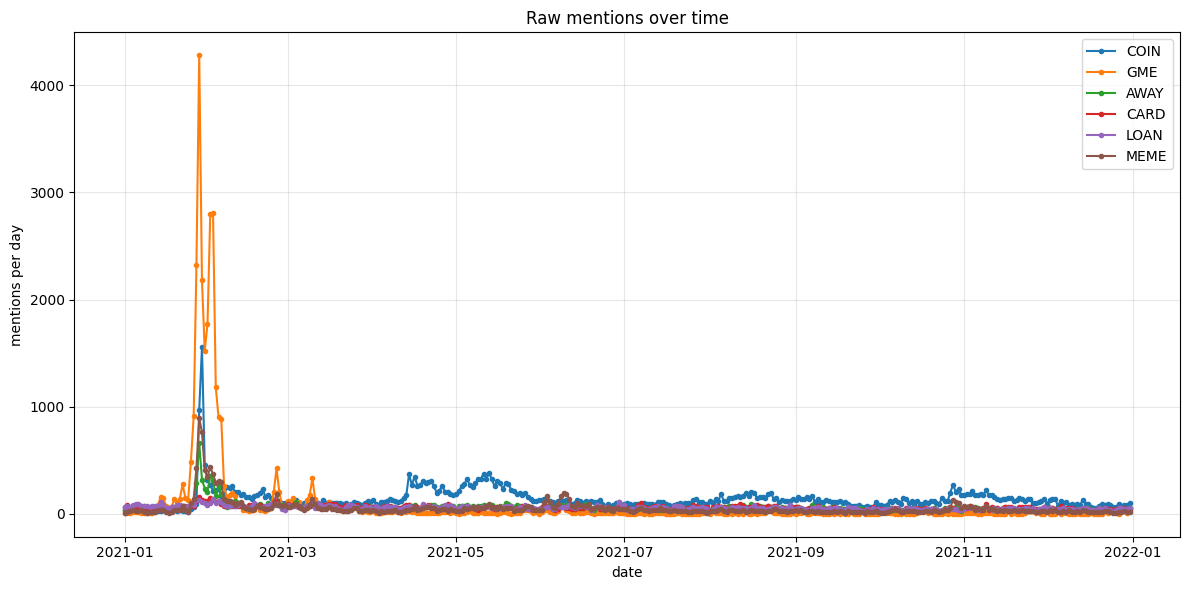

In [54]:
# GRAPH 1 - raw mentions (every post counts as 1)
plot_signal('mention_count', 'Raw mentions over time', 'mentions per day')

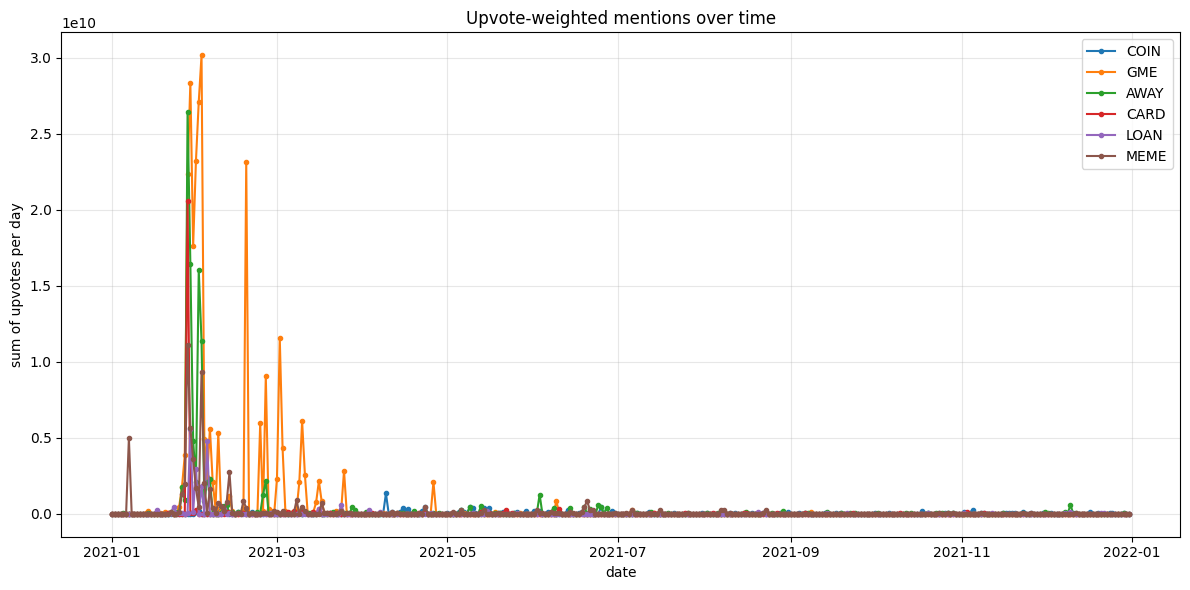

In [55]:
# GRAPH 2 - upvote-weighted mentions (each mention weighted by the post's upvotes)
plot_signal('weighted_count', 'Upvote-weighted mentions over time', 'sum of upvotes per day')

## Raw mention counts - the actual numbers

Tables of the counts behind the plots: all-time totals per ticker, and each
year's top 10 with the year's total. Useful for sanity-checking (and for
spotting false-positive 'tickers' like EDIT or MEME that are really just
words - add those to the stop list in `src/extract_tickers.py`).

In [56]:
# All-time totals per ticker (top 20 by raw mention count).
alltime = (
    daily.groupby('ticker')
    .agg(total_mentions=('mention_count', 'sum'),
         days_active=('date', 'nunique'),
         busiest_day=('mention_count', 'max'))
    .sort_values('total_mentions', ascending=False)
)
alltime.head(20)

,total_mentions,days_active,busiest_day
ticker,,,
COIN,51721,365,1555
GME,30769,336,4281
AWAY,23313,365,662
CARD,22273,365,157
LOAN,21527,365,138
MEME,19601,365,894
LINK,18910,365,523
HODL,17136,365,377
EASY,16812,365,293


In [57]:
# Top 10 tickers per year, with the raw counts.
daily['year'] = daily['date'].dt.year
per_year = daily.groupby(['year', 'ticker'])['mention_count'].sum().reset_index()
top10 = (
    per_year.sort_values(['year', 'mention_count'], ascending=[True, False])
    .groupby('year')
    .head(10)
    .rename(columns={'mention_count': 'total_mentions'})
)
# One row per year, tickers listed with their counts - easy to scan.
for year, grp in top10.groupby('year'):
    row = ', '.join(f"{t} ({c:,})" for t, c in zip(grp['ticker'], grp['total_mentions']))
    print(f'{year}: {row}')

2021: COIN (51,721), GME (30,769), AWAY (23,313), CARD (22,273), LOAN (21,527), MEME (19,601), LINK (18,910), HODL (17,136), EASY (16,812), EARN (16,508)


## Per-year view

One plot **per year**, and each year picks its **own** top tickers.

Why: upvote scores in the archive are *mature* (a 2021 viral post shows its
full 100k upvotes), so on an all-time chart old years dominate both the
ticker choice and the y-axis. Splitting by year means every year competes
only with itself.

In [58]:
# PER-YEAR GRAPHS - each year picks its own top tickers.
YEARLY_TOP_N = 6   # tickers per year

daily['year'] = daily['date'].dt.year

def plot_year(column, ylabel):
    for year in sorted(daily['year'].unique()):
        one_year = daily[daily['year'] == year]
        # This year's OWN ranking (by the same column we're plotting).
        totals = one_year.groupby('ticker')[column].sum().sort_values(ascending=False)
        top = list(totals.head(YEARLY_TOP_N).index)
        if not top:
            continue
        plt.figure(figsize=(12, 5))
        for ticker in top:
            one = one_year[one_year['ticker'] == ticker].sort_values('date')
            plt.plot(one['date'], one[column], marker='o', markersize=2, label=ticker)
        plt.title(f'{year} - top {len(top)} tickers by {column}')
        plt.xlabel('date'); plt.ylabel(ylabel)
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.show()

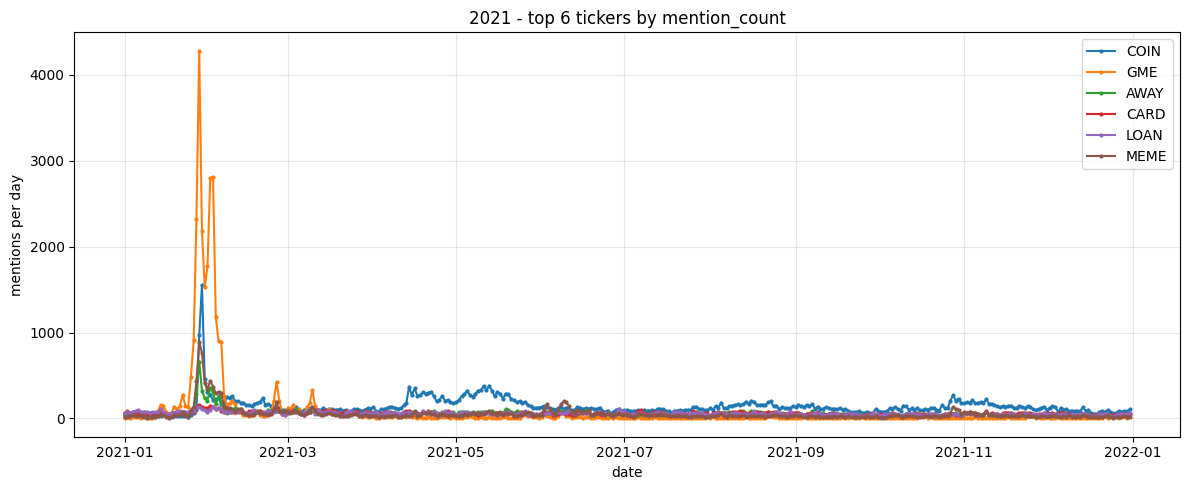

In [59]:
# Per-year GRAPH 1 - raw mentions (every post counts as 1)
plot_year('mention_count', 'mentions per day')

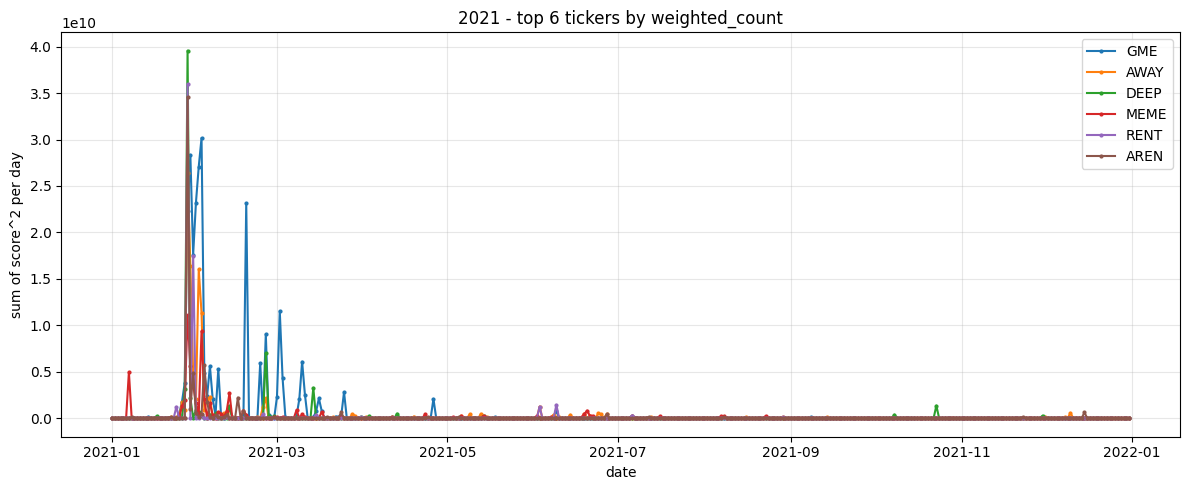

In [60]:
# Per-year GRAPH 2 - upvote-weighted mentions
plot_year('weighted_count', 'sum of score^2 per day')